In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, recall_score, precision_score, confusion_matrix, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import xgboost as xgb # Đổi sang dùng chuẩn XGBoost

import train_model

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Gọi hàm từ file train_model.py của bạn để tải và gộp dữ liệu
print("Đang tải dữ liệu...")
df_raw = train_model.load_and_merge_data()

# Trích xuất Features (X) và Target (y)
X, y = train_model.build_features(df_raw)

# Chia tập dữ liệu (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Đang tải dữ liệu...
Đọc dữ liệu từ: c:\Users\trann\CODE\ProjectMachineLearning\HealthyAI\data
Đã gộp: 10175 mẫu, 21 cột
Số mẫu: 9763 | Features: 18 | Positive rate (ĐTĐ): 0.0755
Kích thước tập Train: (7810, 18)
Kích thước tập Test: (1953, 18)


In [3]:
import time
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import train_model # Import file của bạn

# GỌI TRỰC TIẾP HÀM KHỞI TẠO TỪ FILE .py CỦA BẠN (Đảm bảo khớp 100% tham số)
models_dict = train_model.build_models(y_train)

trained_models = {}
training_times = []

print("Bắt đầu huấn luyện và đo thời gian...")
for name, clf in models_dict.items():
    # Vẫn giữ nguyên Pipeline chuẩn hóa
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', clf)
    ])
    
    start_time = time.time()
    pipe.fit(X_train, y_train)
    end_time = time.time()
    
    elapsed_time = end_time - start_time
    trained_models[name] = pipe
    training_times.append({'Mô hình': name, 'Thời gian (giây)': round(elapsed_time, 4)})
    print(f"✅ Đã huấn luyện xong: {name} ({elapsed_time:.2f}s)")

df_times = pd.DataFrame(training_times)
display(df_times)

[XGBoost] scale_pos_weight = 12.24
Bắt đầu huấn luyện và đo thời gian...
✅ Đã huấn luyện xong: Logistic Regression (0.02s)
✅ Đã huấn luyện xong: Random Forest (1.26s)
✅ Đã huấn luyện xong: Extra Trees (0.68s)
✅ Đã huấn luyện xong: XGBoost (0.56s)


,Mô hình,Thời gian (giây)
0,Logistic Regression,0.0246
1,Random Forest,1.2559
2,Extra Trees,0.6817
3,XGBoost,0.5623


In [4]:
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix

metrics_data = []
cms = {}

print("Bắt đầu đánh giá hiệu suất trên tập Test...")
for name, pipe in trained_models.items():
    y_probs = pipe.predict_proba(X_test)[:, 1]
    
    # GỌI TRỰC TIẾP HÀM TÌM THRESHOLD TỪ FILE .py CỦA BẠN
    # Điều này đảm bảo công thức toán học tính F0.75 giống hệt Terminal
    opt_thresh = train_model.find_optimal_threshold(y_test, y_probs)
    
    y_pred = (y_probs >= opt_thresh).astype(int)
    
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    metrics_data.append({
        'Mô hình': name,
        'Threshold': opt_thresh,
        'F1-Score': f1,
        'Recall': rec,
        'Precision': prec
    })
    
    cms[name] = confusion_matrix(y_test, y_pred)

df_metrics = pd.DataFrame(metrics_data)
display(df_metrics)

Bắt đầu đánh giá hiệu suất trên tập Test...
  → Optimal threshold: 0.9127  (F0.75 = 0.7065)
  → Optimal threshold: 0.6010  (F0.75 = 0.7031)
  → Optimal threshold: 0.8055  (F0.75 = 0.6538)
  → Optimal threshold: 0.6210  (F0.75 = 0.7147)


,Mô hình,Threshold,F1-Score,Recall,Precision
0,Logistic Regression,0.912719,0.688889,0.632653,0.756098
1,Random Forest,0.600972,0.713826,0.755102,0.676829
2,Extra Trees,0.805548,0.606838,0.482993,0.816092
3,XGBoost,0.621032,0.723127,0.755102,0.693750


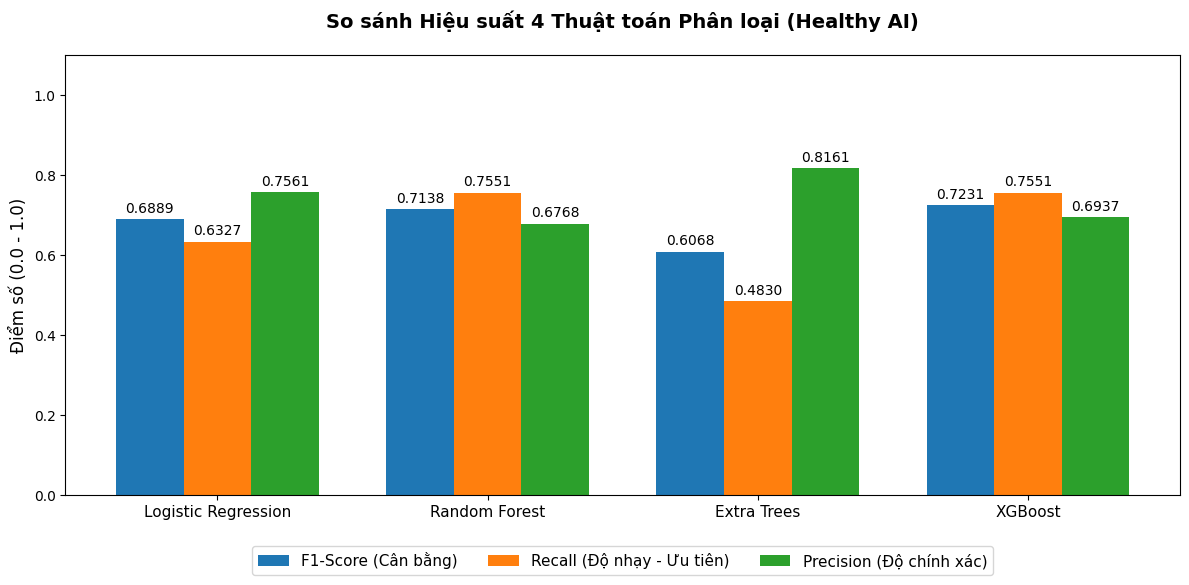

In [5]:
# Lấy dữ liệu từ df_metrics
models = df_metrics['Mô hình'].tolist()
f1_scores = df_metrics['F1-Score'].tolist()
recalls = df_metrics['Recall'].tolist()
precisions = df_metrics['Precision'].tolist()

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, f1_scores, width, label='F1-Score (Cân bằng)', color='#1f77b4')
rects2 = ax.bar(x, recalls, width, label='Recall (Độ nhạy - Ưu tiên)', color='#ff7f0e')
rects3 = ax.bar(x + width, precisions, width, label='Precision (Độ chính xác)', color='#2ca02c')

ax.set_ylabel('Điểm số (0.0 - 1.0)', fontsize=12)
ax.set_title('So sánh Hiệu suất 4 Thuật toán Phân loại (Healthy AI)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.1) # Dư ra một chút để vẽ label
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=11)

# Hàm ghi số lên cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

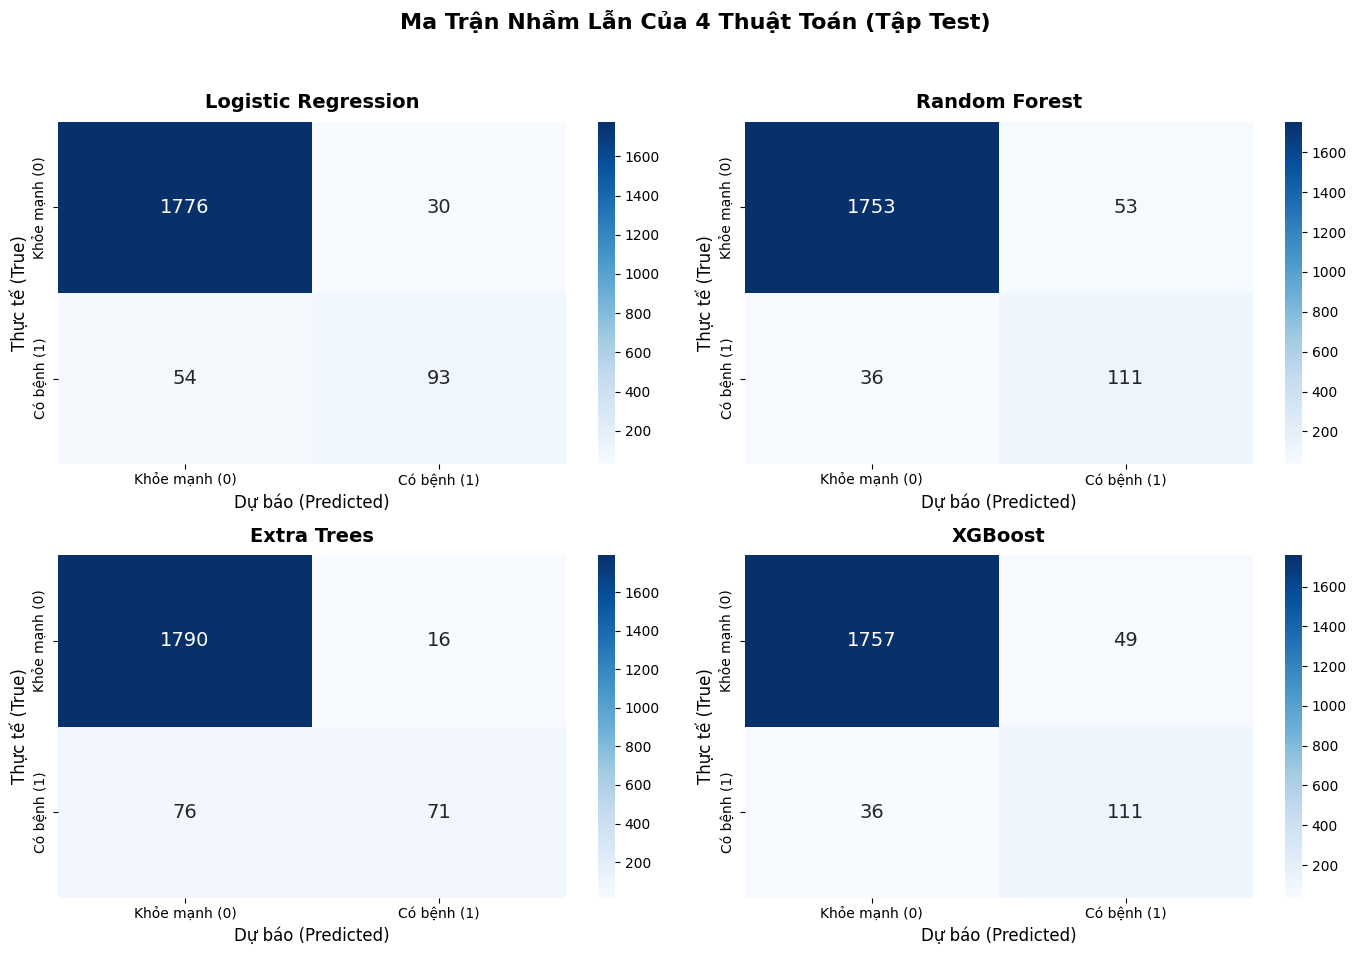

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, name in enumerate(models):
    cm = cms[name]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], annot_kws={"size": 14})
    
    axes[i].set_title(f'{name}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Dự báo (Predicted)', fontsize=12)
    axes[i].set_ylabel('Thực tế (True)', fontsize=12)
    axes[i].set_xticklabels(['Khỏe mạnh (0)', 'Có bệnh (1)'])
    axes[i].set_yticklabels(['Khỏe mạnh (0)', 'Có bệnh (1)'])

plt.suptitle("Ma Trận Nhầm Lẫn Của 4 Thuật Toán (Tập Test)", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Chừa chỗ cho suptitle
plt.show()

Đọc dữ liệu từ: c:\Users\trann\CODE\ProjectMachineLearning\HealthyAI\data
Đã gộp: 10175 mẫu, 21 cột
Số mẫu: 9763 | Positive rate: 0.0755

Đang huấn luyện và tìm cấu hình vô địch cho từng thuật toán (Quá trình này mất khoảng 1-2 phút)...

Hoàn tất! Danh sách các cấu hình tốt nhất được đem đi vẽ biểu đồ:
🏆 Logistic Regression: LR | C=0.01 (F1 = 0.6894)
🏆 Random Forest: RF | max_depth=15 (F1 = 0.7279)
🏆 Extra Trees: ET | max_depth=None (F1 = 0.6538)
🏆 XGBoost: XGB | learning_rate=0.01 (F1 = 0.7450)


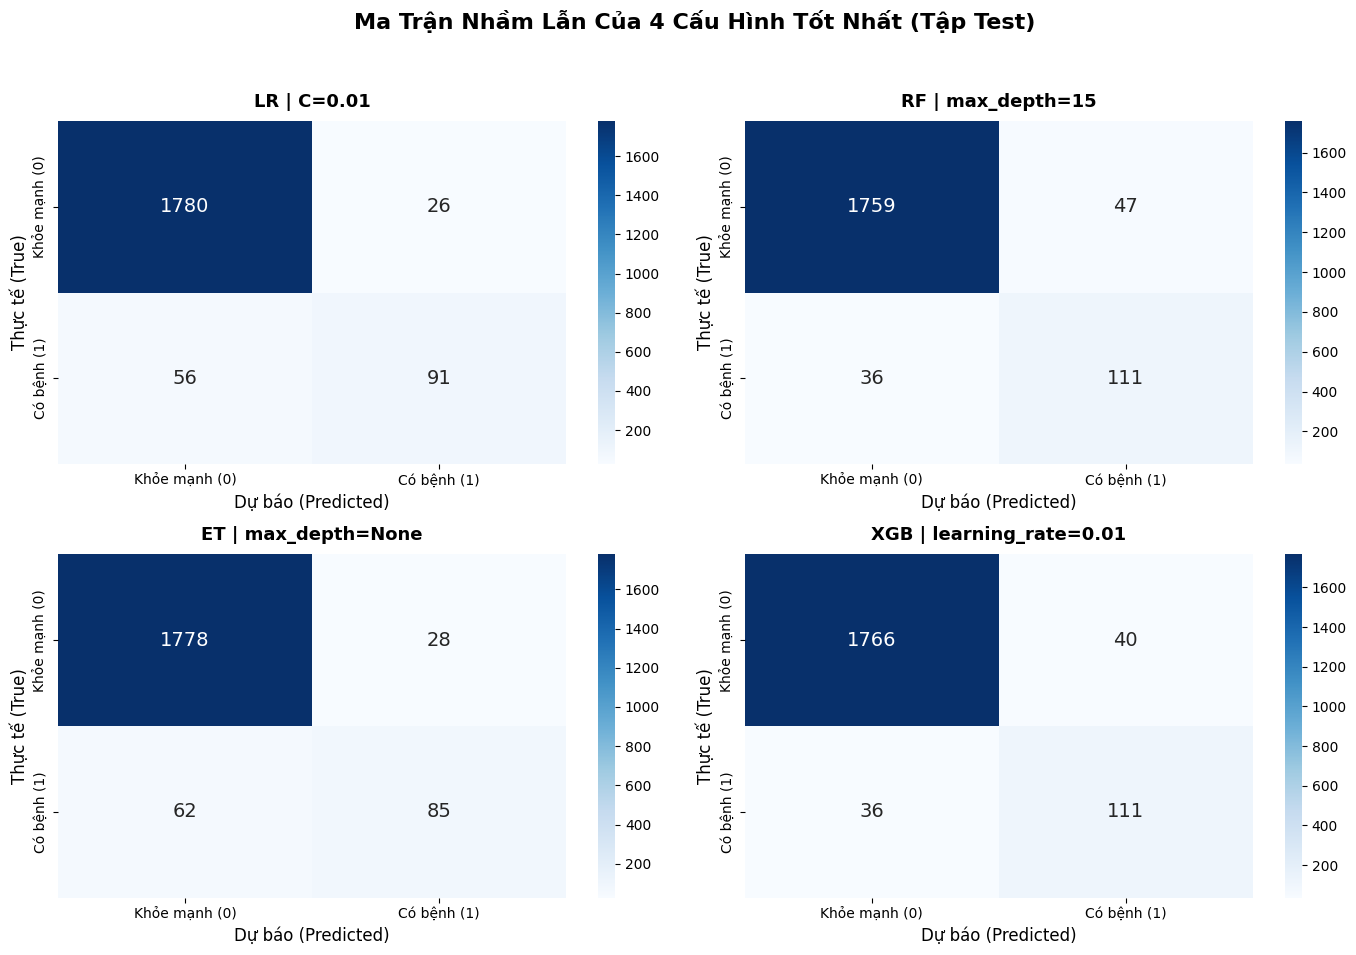

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix

import train_model # Import file của bạn

# 1. Tải dữ liệu và chia tập Train/Test (Đảm bảo khớp 100% với file gốc)
df = train_model.load_and_merge_data()
X, y = train_model.build_features(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Khởi tạo từ điển để lưu cấu hình "Vô địch" của từng dòng thuật toán
best_models = {
    'Logistic Regression': {'f1': -1, 'cm': None, 'name': ''},
    'Random Forest': {'f1': -1, 'cm': None, 'name': ''},
    'Extra Trees': {'f1': -1, 'cm': None, 'name': ''},
    'XGBoost': {'f1': -1, 'cm': None, 'name': ''}
}

# Hàm phụ để nhận diện thuật toán dựa vào tên thí nghiệm
def get_family_name(exp_name):
    if exp_name.startswith('LR'): return 'Logistic Regression'
    if exp_name.startswith('RF'): return 'Random Forest'
    if exp_name.startswith('ET'): return 'Extra Trees'
    if exp_name.startswith('XGB'): return 'XGBoost'
    return 'Unknown'

print("Đang huấn luyện và tìm cấu hình vô địch cho từng thuật toán (Quá trình này mất khoảng 1-2 phút)...")

# 3. Lặp qua tất cả các thí nghiệm trong file của bạn
for exp in train_model.EXPERIMENTS:
    name = exp['name']
    clf = exp['model']
    family = get_family_name(name)
    
    if family == 'Unknown': continue
        
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     clf),
    ])
    
    # Huấn luyện
    pipe.fit(X_train, y_train)
    
    # Tìm ngưỡng tối ưu và tính F1
    y_proba = pipe.predict_proba(X_test)[:, 1]
    opt_th = train_model.find_optimal_threshold(y_test, y_proba)
    y_pred = (y_proba >= opt_th).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Nếu cấu hình này có F1 cao hơn cấu hình cũ cùng dòng thuật toán -> Cập nhật lên top 1
    if f1 > best_models[family]['f1']:
        best_models[family]['f1'] = f1
        best_models[family]['cm'] = confusion_matrix(y_test, y_pred)
        best_models[family]['name'] = name

# In ra các cấu hình dẫn đầu
print("\nHoàn tất! Danh sách các cấu hình tốt nhất được đem đi vẽ biểu đồ:")
for fam, data in best_models.items():
    if data['cm'] is not None:
        print(f"🏆 {fam}: {data['name']} (F1 = {data['f1']:.4f})")

# 4. Vẽ 4 Ma Trận Nhầm Lẫn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

families = ['Logistic Regression', 'Random Forest', 'Extra Trees', 'XGBoost']

for i, fam in enumerate(families):
    cm = best_models[fam]['cm']
    best_name = best_models[fam]['name']
    
    if cm is not None:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], annot_kws={"size": 14})
        
        axes[i].set_title(f"{best_name}", fontsize=13, fontweight='bold', pad=10)
        axes[i].set_xlabel('Dự báo (Predicted)', fontsize=12)
        axes[i].set_ylabel('Thực tế (True)', fontsize=12)
        axes[i].set_xticklabels(['Khỏe mạnh (0)', 'Có bệnh (1)'])
        axes[i].set_yticklabels(['Khỏe mạnh (0)', 'Có bệnh (1)'])

plt.suptitle("Ma Trận Nhầm Lẫn Của 4 Cấu Hình Tốt Nhất (Tập Test)", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Chừa chỗ cho suptitle
plt.show()